# AIoT Project

In [11]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [3]:
time_start = time()

## Load configuration

In [4]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [5]:
client = pymongo.MongoClient(config["client"])

In [6]:
db = client[config["db"]]
coll = db[config["col"]]

In [7]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 25 keys in the collection


## Load data

In [8]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({}, {"data": True, "gesture_id": True}))
print(f'Found {len(results)} keys in the collection')

Found 25 keys in the collection


In [9]:
all_chunks = pd.DataFrame(results)
# print(len(all_chunks))

ids = all_chunks['gesture_id'].unique().tolist()
# print(ids)

gestures = {}
for id in ids:
    gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
    current_data = gesture_chunks['data']
    
    chunks = []
    for chunk in current_data:
        # print(chunk)
        df = pd.DataFrame(chunk)
        dp = df.drop(df.tail(200).index, inplace=True)
        dp = df.drop(df.head(200).index, inplace=True)
        chunks.append((id, df))

    joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
    gestures[id] = joined_gesture

    # print(len(chunks[0][1]))
    # print(chunks[0][1].head())

    # print(len(joined_gesture))
    # print(joined_gesture.head())
    
    
print(len(gestures))
print(gestures['scroll-up-index'])


5
       acc_x  acc_y  acc_z  gyr_x   gyr_y  gyr_z
0     -0.086 -0.269  0.960  0.122   2.317 -0.671
1     -0.093 -0.268  0.964  0.671   4.085 -1.768
2     -0.097 -0.268  0.962  1.707   6.585 -3.232
3     -0.089 -0.266  0.962  2.683   9.939 -5.122
4     -0.095 -0.268  0.958  3.963  12.866 -7.378
...      ...    ...    ...    ...     ...    ...
33552 -0.160 -0.445  0.876  2.195  -2.500  0.732
33553 -0.164 -0.447  0.870  2.805  -2.683  0.427
33554 -0.157 -0.447  0.869  3.293  -2.744  0.000
33555 -0.148 -0.446  0.872  3.902  -1.707 -0.732
33556 -0.152 -0.448  0.872  5.183   0.549 -2.012

[33557 rows x 6 columns]


## Explore the nature of the data

Gesture: scroll-down-index


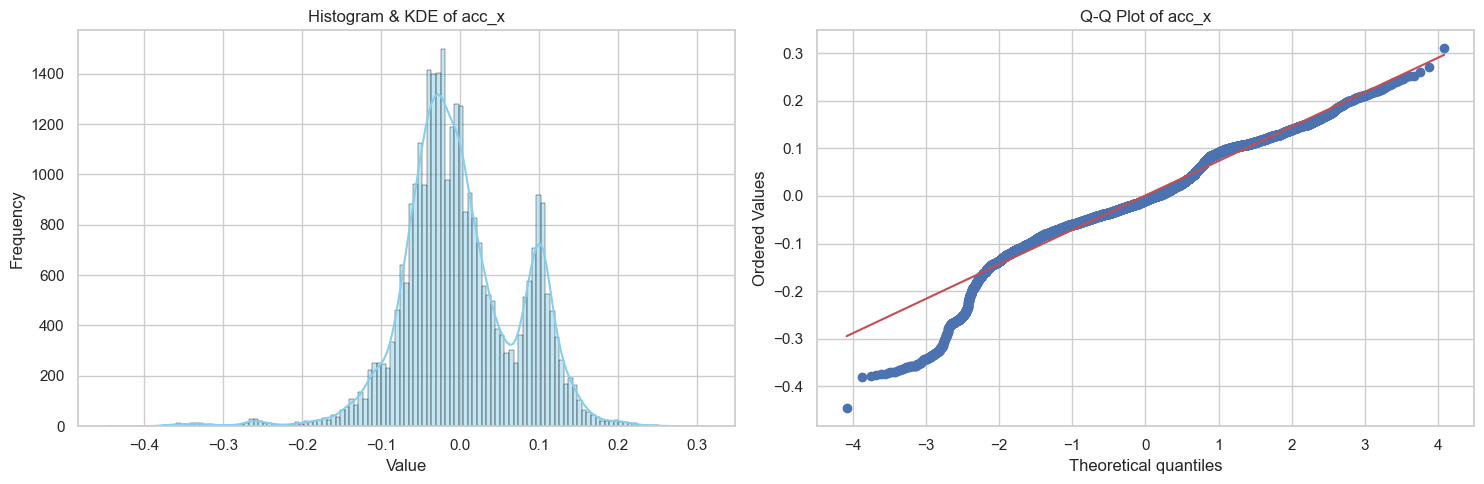

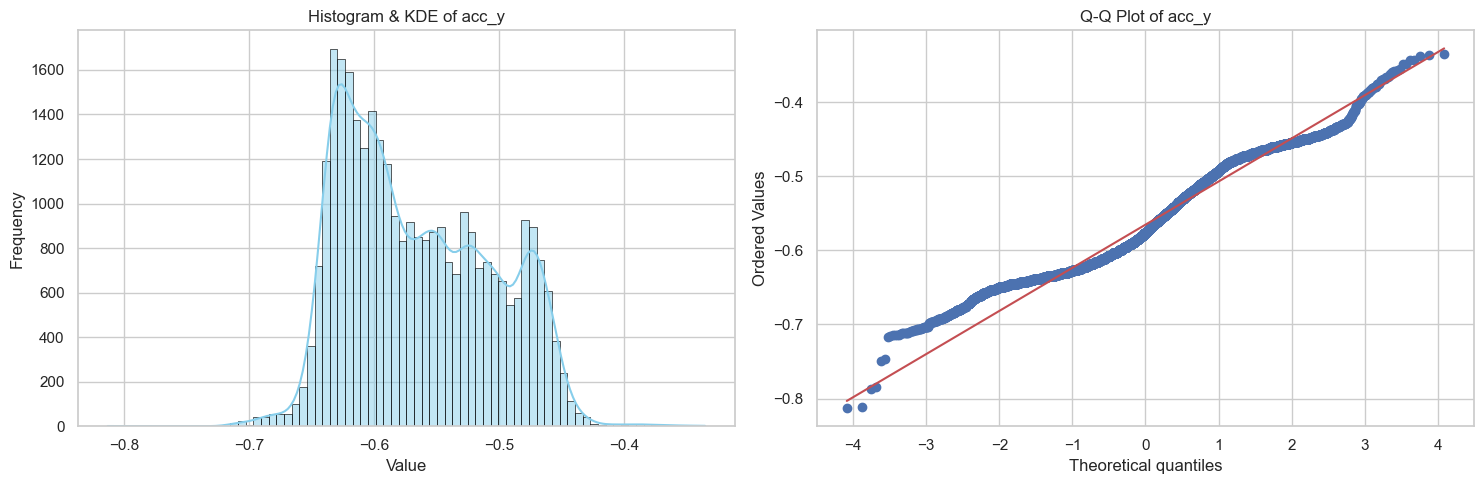

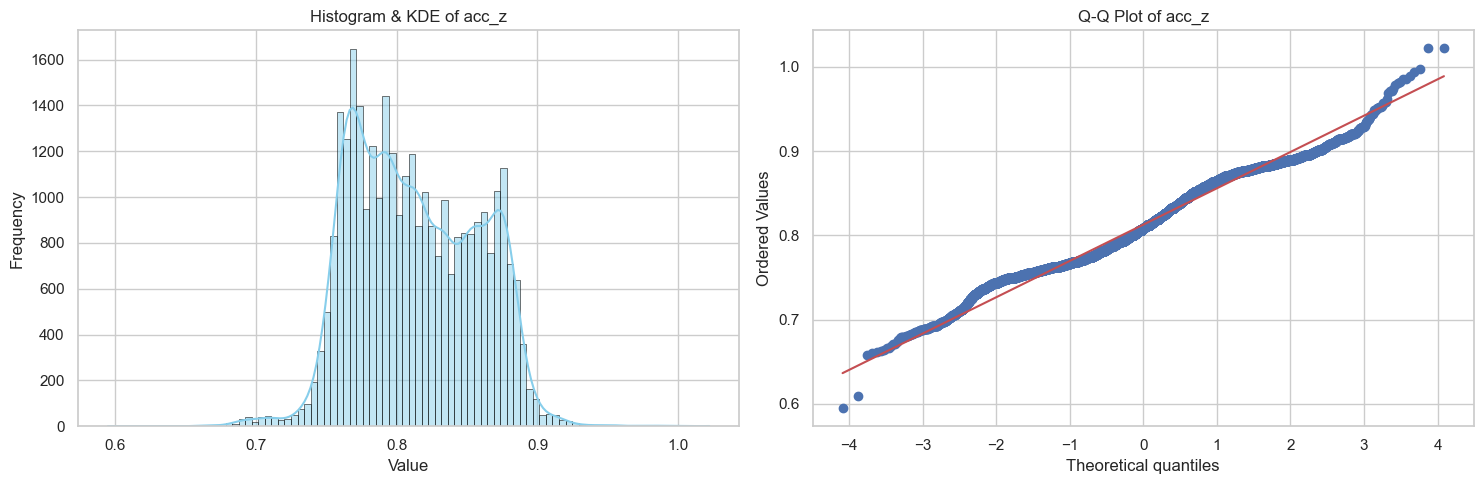

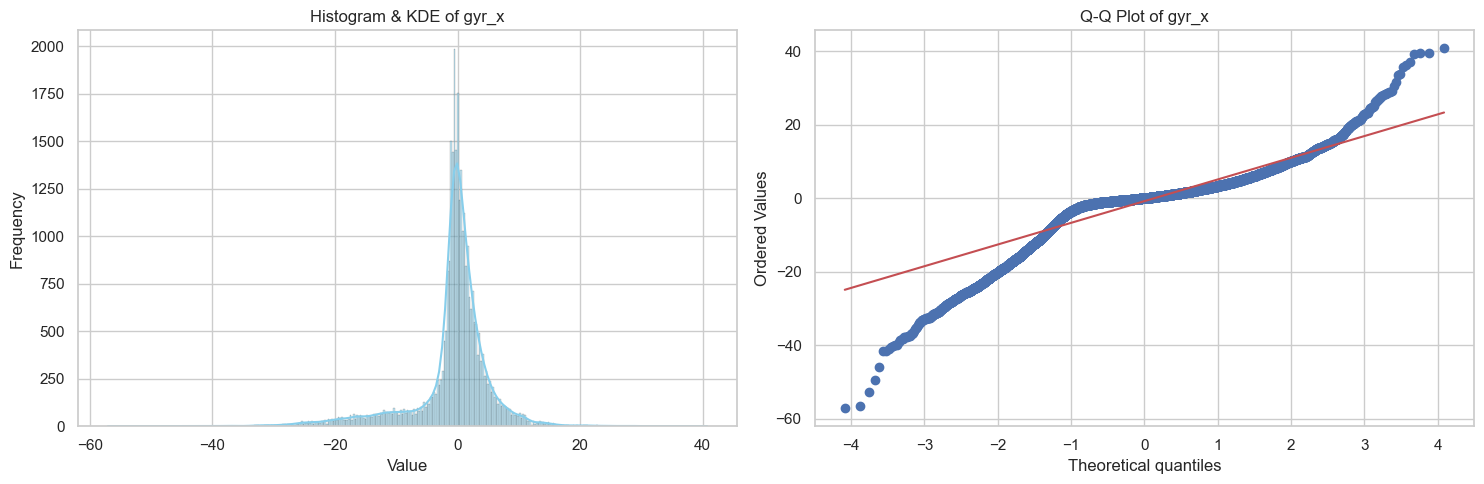

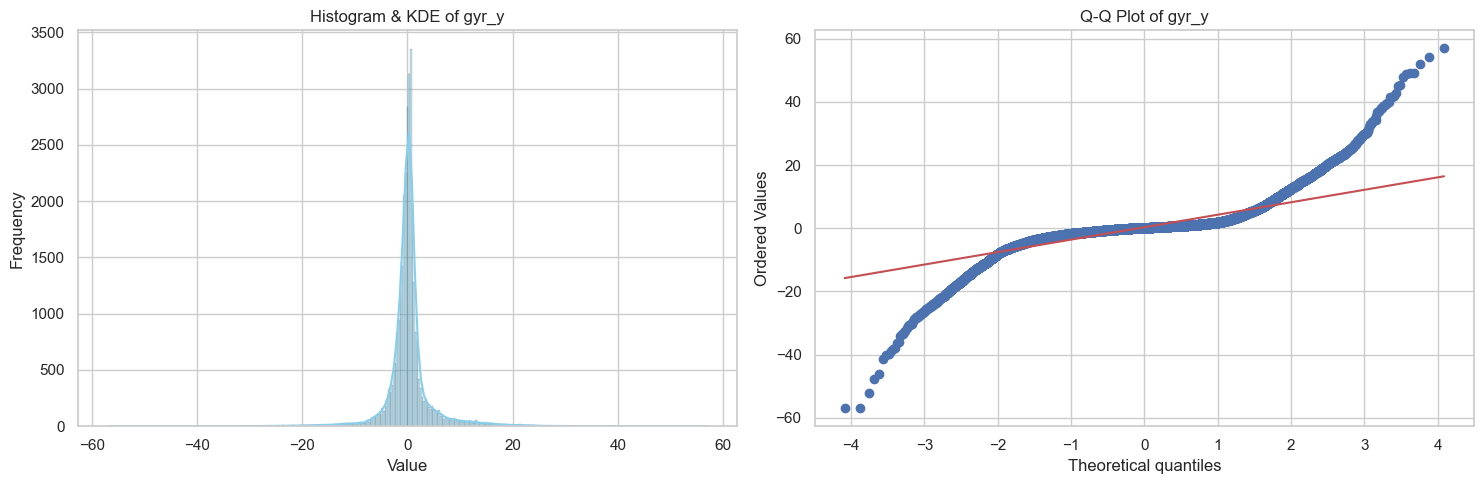

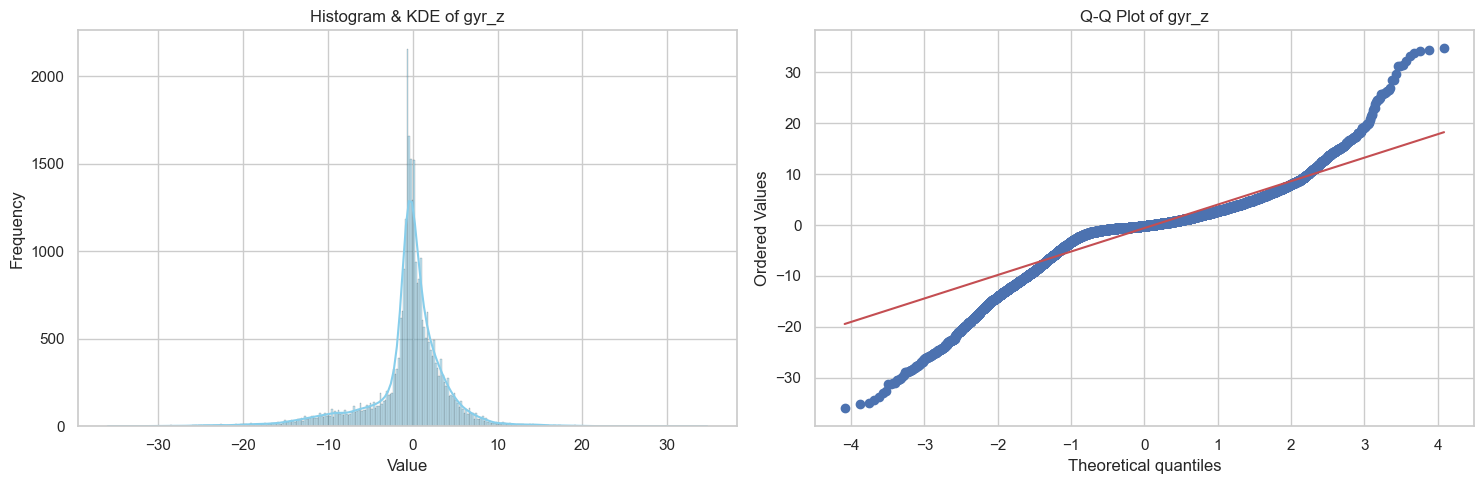

In [15]:
keys = gestures['scroll-up-index'].columns
for id, gesture in gestures.items():
    print(f'Gesture: {id}')
    for key in keys:
        plot_distribution_analysis(gesture, column_name=key)
    break

             Gesture  Duration (s)
0  scroll-down-index        316.85
1    scroll-up-index        335.57
2     texting-single        315.20
3  swipe-right-index        319.22
4   swipe-left-index        329.29


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/utils_visual.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


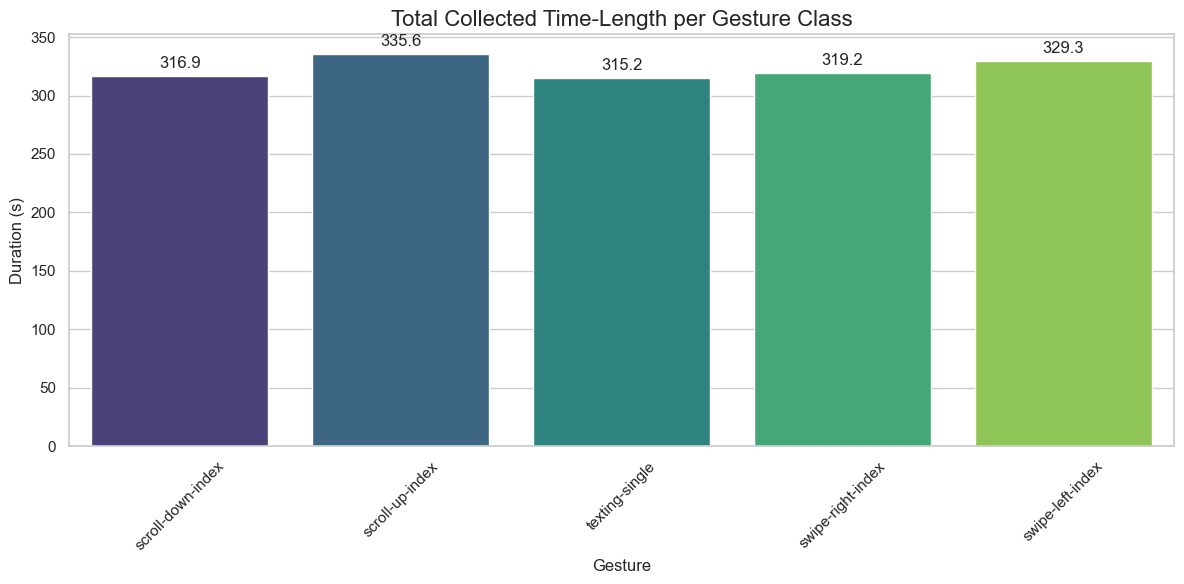

In [ ]:
sampling_rate = 100
durations = []
for gesture_id, df in gestures.items():
    total_samples = len(df)
    duration_seconds = total_samples / sampling_rate
    durations.append({'Gesture': gesture_id, 'Duration (s)':
        duration_seconds})

duration_df = pd.DataFrame(durations)
print(duration_df)
   
plot_bar(duration_df, title='Total Collected Time-Length per Gesture Class')

## Data Processing

In [11]:
# df = dfs[0]
# print('FOCUSING ON ', df[0])
# data = df[1]
# plot_instance_time_domain(data)
# # plot_instance_3d(data, axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
# plot_instance_3d(data, axes_list=['acc_x', 'acc_y', 'acc_z'])
# plot_heatmap(data)

# # slice data into windows
# clips = sliding_window_pd(data, ws=2000, overlap=1000, print_stats=False)
# total_clips = len(clips)
# print(f'Total clips: {total_clips}')
# fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
# plot_instance_time_domain(fclips[1])
# # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
# plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])


We Filter for Glitches/Outliers

Cleaning gesture: scroll-down-index
Cleaned 54 glitches in acc_x
Cleaned 17 glitches in acc_y
Cleaned 25 glitches in acc_z
Cleaned 4 glitches in gyr_x
Cleaned 24 glitches in gyr_y
Cleaned 7 glitches in gyr_z
Cleaning gesture: scroll-up-index
Cleaned 75 glitches in acc_x
Cleaned 15 glitches in acc_y
Cleaned 5 glitches in acc_z
Cleaned 5 glitches in gyr_x
Cleaned 17 glitches in gyr_y
Cleaned 6 glitches in gyr_z
Cleaning gesture: texting-single
Cleaned 140 glitches in acc_x
Cleaned 180 glitches in acc_y
Cleaned 49 glitches in acc_z
Cleaned 10 glitches in gyr_x
Cleaned 60 glitches in gyr_y
Cleaned 17 glitches in gyr_z
Cleaning gesture: swipe-right-index
Cleaned 65 glitches in acc_x
Cleaned 27 glitches in acc_y
Cleaned 27 glitches in acc_z
Cleaned 23 glitches in gyr_x
Cleaned 40 glitches in gyr_y
Cleaned 0 glitches in gyr_z
Cleaning gesture: swipe-left-index
Cleaned 46 glitches in acc_x
Cleaned 16 glitches in acc_y
Cleaned 12 glitches in acc_z
Cleaned 7 glitches in gyr_x
Cleaned 14 glitches

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
0,-0.086,-0.269,0.960,0.122,2.317,-0.671
1,-0.093,-0.268,0.964,0.671,4.085,-1.768
2,-0.097,-0.268,0.962,1.707,6.585,-3.232
3,-0.089,-0.266,0.962,2.683,9.939,-5.122
4,-0.095,-0.268,0.958,3.963,12.866,-7.378


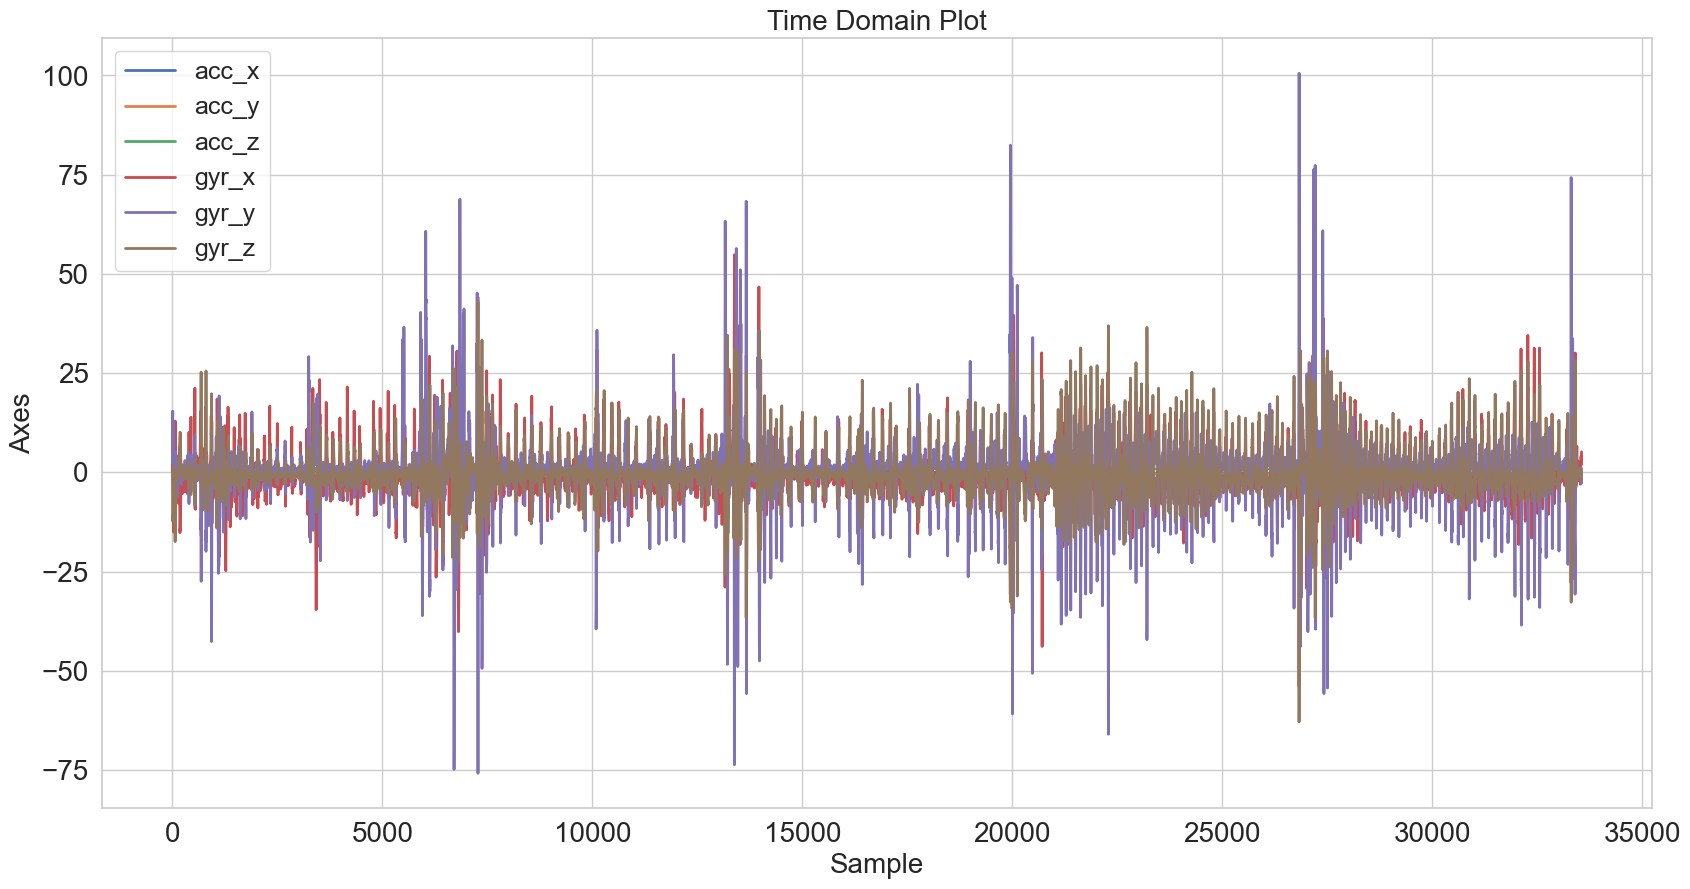

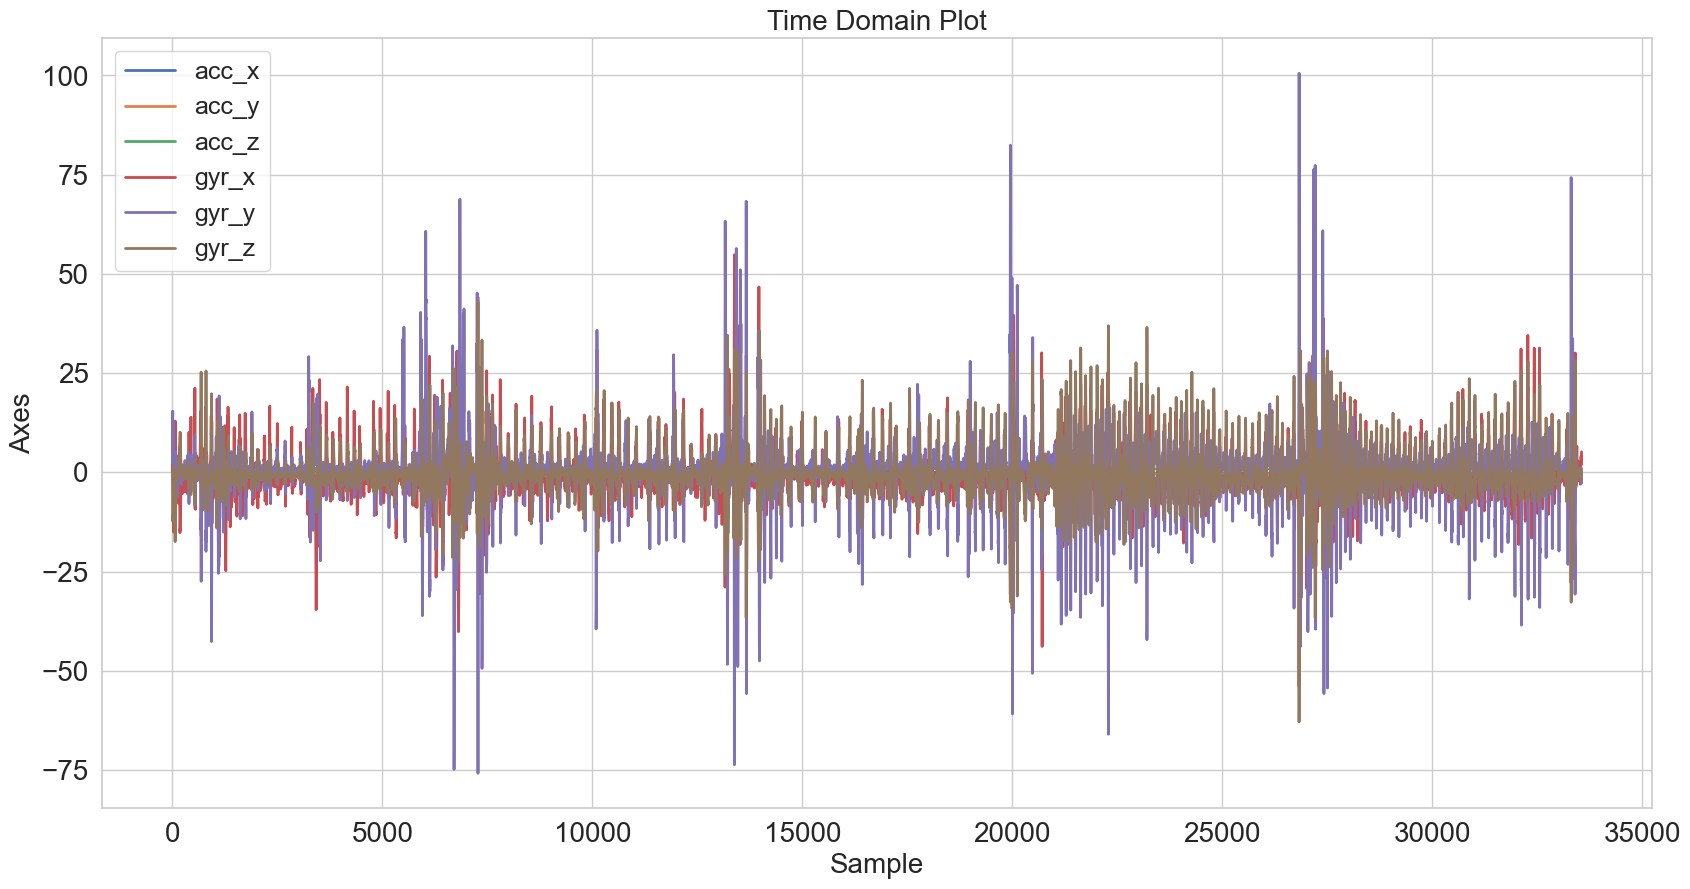

In [12]:


def clean_sensor_outliers(df, window_size=50, threshold=3.0):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    # Create a copy so we don't accidentally overwrite your raw data
    df_clean = df.copy()
    
    # Define your 6 sensor columns from the MetaMotionR IMU
    sensor_columns = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    
    for col in sensor_columns:
        # 1. Calculate Rolling Mean and Standard Deviation
        # 'center=True' ensures the window looks at points both before and after the current row
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        # 2. Calculate the Rolling Z-Score
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        
        # 3. Find how many outliers we are catching (Great for your EDA Report!)
        outlier_count = (rolling_z_scores > threshold).sum()
        print(f"Cleaned {outlier_count} glitches in {col}")
        
        # 4. Replace those specific outliers with NaN
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        
        # 5. Apply Linear Interpolation to smoothly connect the gaps
        # limit_direction='both' ensures it fixes glitches even if they happen on the very first or last row
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean


cleaned_gestures = {}
for gesture_id, gesture_df in gestures.items():
    print(f'Cleaning gesture: {gesture_id}')
    gesture_cleaned = clean_sensor_outliers(gesture_df)
    cleaned_gestures[gesture_id] = gesture_cleaned

# Check the first few rows to ensure everything looks correct
display(cleaned_gestures['scroll-up-index'].head())
plot_instance_time_domain(cleaned_gestures['scroll-up-index'])
plot_instance_time_domain(cleaned_gestures['scroll-up-index'])


In [13]:
# strucure of cleaned_gestures:
print(type(cleaned_gestures))
print(cleaned_gestures.keys())
print(len(cleaned_gestures))
print(len(cleaned_gestures['scroll-down-index']))
print(cleaned_gestures['scroll-down-index'])

<class 'dict'>
dict_keys(['scroll-down-index', 'scroll-up-index', 'texting-single', 'swipe-right-index', 'swipe-left-index'])
5
31685
       acc_x  acc_y  acc_z  gyr_x  gyr_y  gyr_z
0      0.000 -0.503  0.842  3.171  2.744  1.463
1      0.001 -0.505  0.844  3.780  3.659  1.829
2     -0.004 -0.511  0.842  5.305  3.902  2.317
3     -0.003 -0.510  0.838  6.646  3.841  3.293
4      0.001 -0.510  0.833  7.439  3.841  4.634
...      ...    ...    ...    ...    ...    ...
31680 -0.002 -0.604  0.787  3.232  0.488 -2.439
31681 -0.009 -0.596  0.792  3.902  0.427 -2.866
31682 -0.008 -0.596  0.792  4.573  0.427 -3.598
31683 -0.000 -0.598  0.792  5.671  1.098 -4.695
31684  0.007 -0.591  0.803  6.768  3.841 -6.524

[31685 rows x 6 columns]


## Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

gestures_train = {}
gestures_val = {}
for id, data in cleaned_gestures.items():
    id_arr = np.array([id] * len(data))
    X_train, X_val, y_train, y_val = train_test_split(data, id_arr, test_size=0.20, shuffle=False)
    gestures_train[id] = X_train
    gestures_val[id] = X_val

print("gestures_train keys: ", gestures_train.keys(), "\nlength: ", len(gestures_train))
print("gestures_val keys: ", gestures_val.keys(), "\nlength: ", len(gestures_val))
print("Example X_train shape: ", gestures_train['scroll-up-index'])

gestures_train keys:  dict_keys(['scroll-down-index', 'scroll-up-index', 'texting-single', 'swipe-right-index', 'swipe-left-index']) 
length:  5
gestures_val keys:  dict_keys(['scroll-down-index', 'scroll-up-index', 'texting-single', 'swipe-right-index', 'swipe-left-index']) 
length:  5
Example X_train shape:         acc_x  acc_y  acc_z  gyr_x   gyr_y  gyr_z
0     -0.086 -0.269  0.960  0.122   2.317 -0.671
1     -0.093 -0.268  0.964  0.671   4.085 -1.768
2     -0.097 -0.268  0.962  1.707   6.585 -3.232
3     -0.089 -0.266  0.962  2.683   9.939 -5.122
4     -0.095 -0.268  0.958  3.963  12.866 -7.378
...      ...    ...    ...    ...     ...    ...
26840 -0.225 -0.542  0.703 -5.244  16.585 -6.829
26841 -0.261 -0.539  0.713 -3.963  11.341 -4.268
26842 -0.290 -0.542  0.724 -3.232   5.549 -1.768
26843 -0.312 -0.548  0.741 -2.927   0.549 -0.244
26844 -0.324 -0.549  0.760 -3.537  -3.537  0.854

[26845 rows x 6 columns]


## Sensor-type grouped scaling

In [41]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
robust_scaler = RobustScaler()

all_train_data = pd.concat(gestures_train.values())
std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

for id in gestures_train:
    gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
    gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
    
for id in gestures_val:
    gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
    gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])

## We use sliding widnowing to create our samples

Number of filtered instances in the list: 24
GESTURE_ID: scroll-down-index
Number of filtered instances in the list: 25
GESTURE_ID: scroll-up-index
Number of filtered instances in the list: 24
GESTURE_ID: texting-single
Number of filtered instances in the list: 24
GESTURE_ID: swipe-right-index
Number of filtered instances in the list: 25
GESTURE_ID: swipe-left-index
Number of filtered instances in the list: 5
GESTURE_ID: scroll-down-index
Number of filtered instances in the list: 5
GESTURE_ID: scroll-up-index
Number of filtered instances in the list: 5
GESTURE_ID: texting-single
Number of filtered instances in the list: 5
GESTURE_ID: swipe-right-index
Number of filtered instances in the list: 5
GESTURE_ID: swipe-left-index
clipped_train keys:  dict_keys(['scroll-down-index', 'scroll-up-index', 'texting-single', 'swipe-right-index', 'swipe-left-index']) 
length:  5
clipped_val keys:  dict_keys(['scroll-down-index', 'scroll-up-index', 'texting-single', 'swipe-right-index', 'swipe-left-in

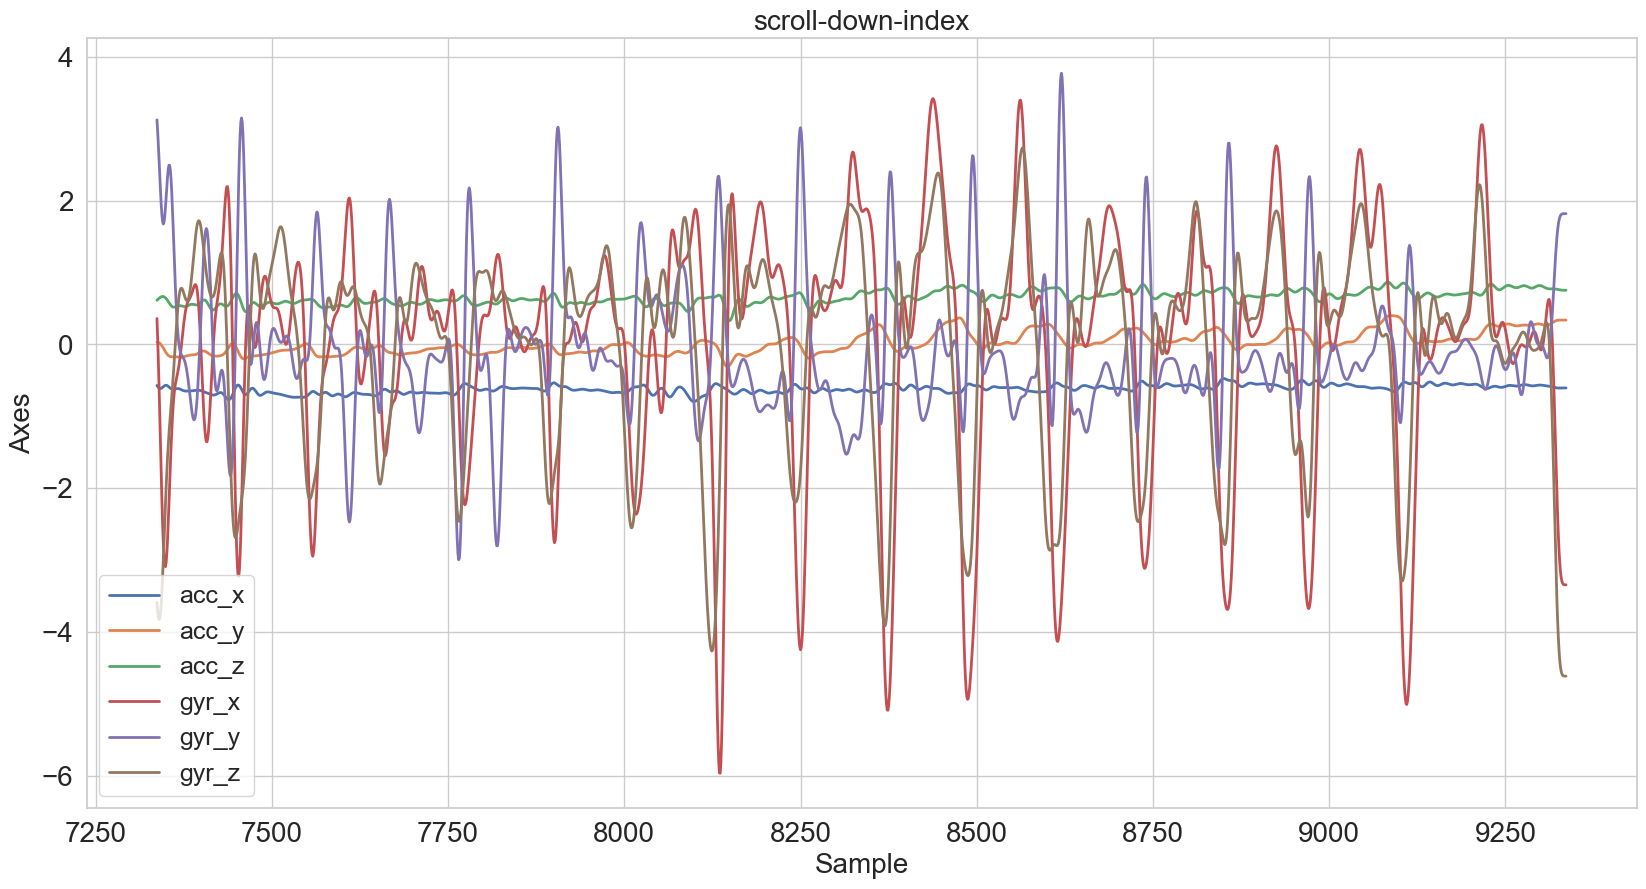

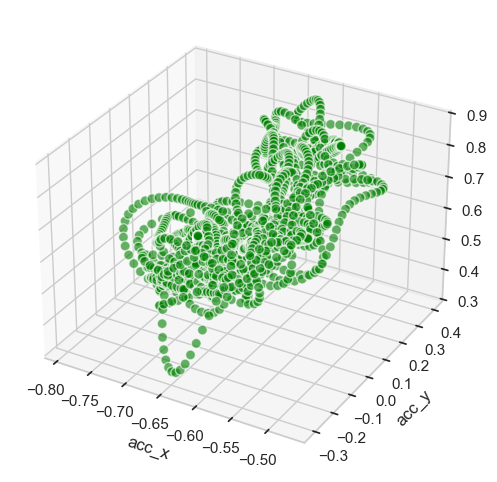

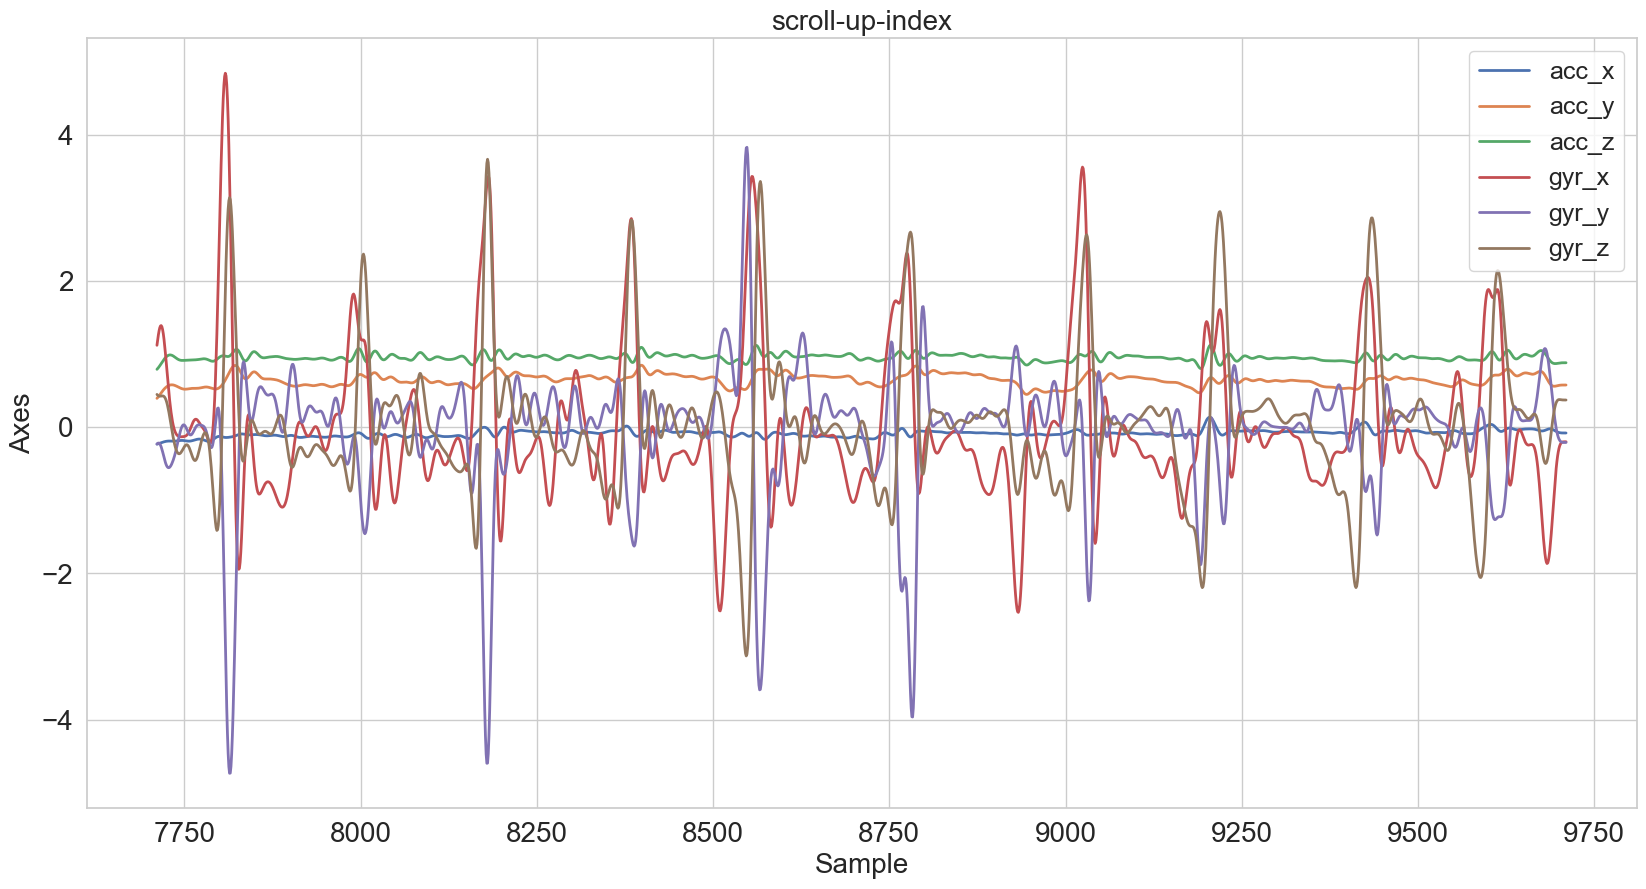

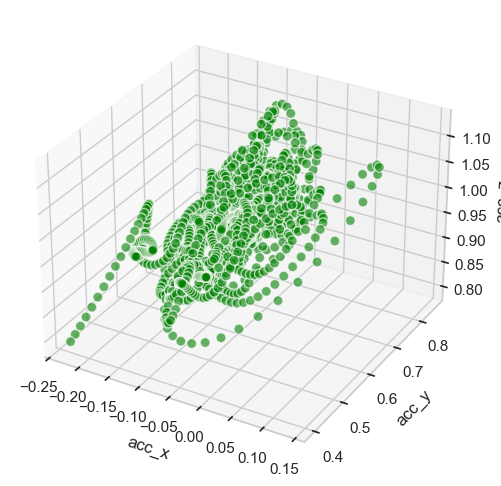

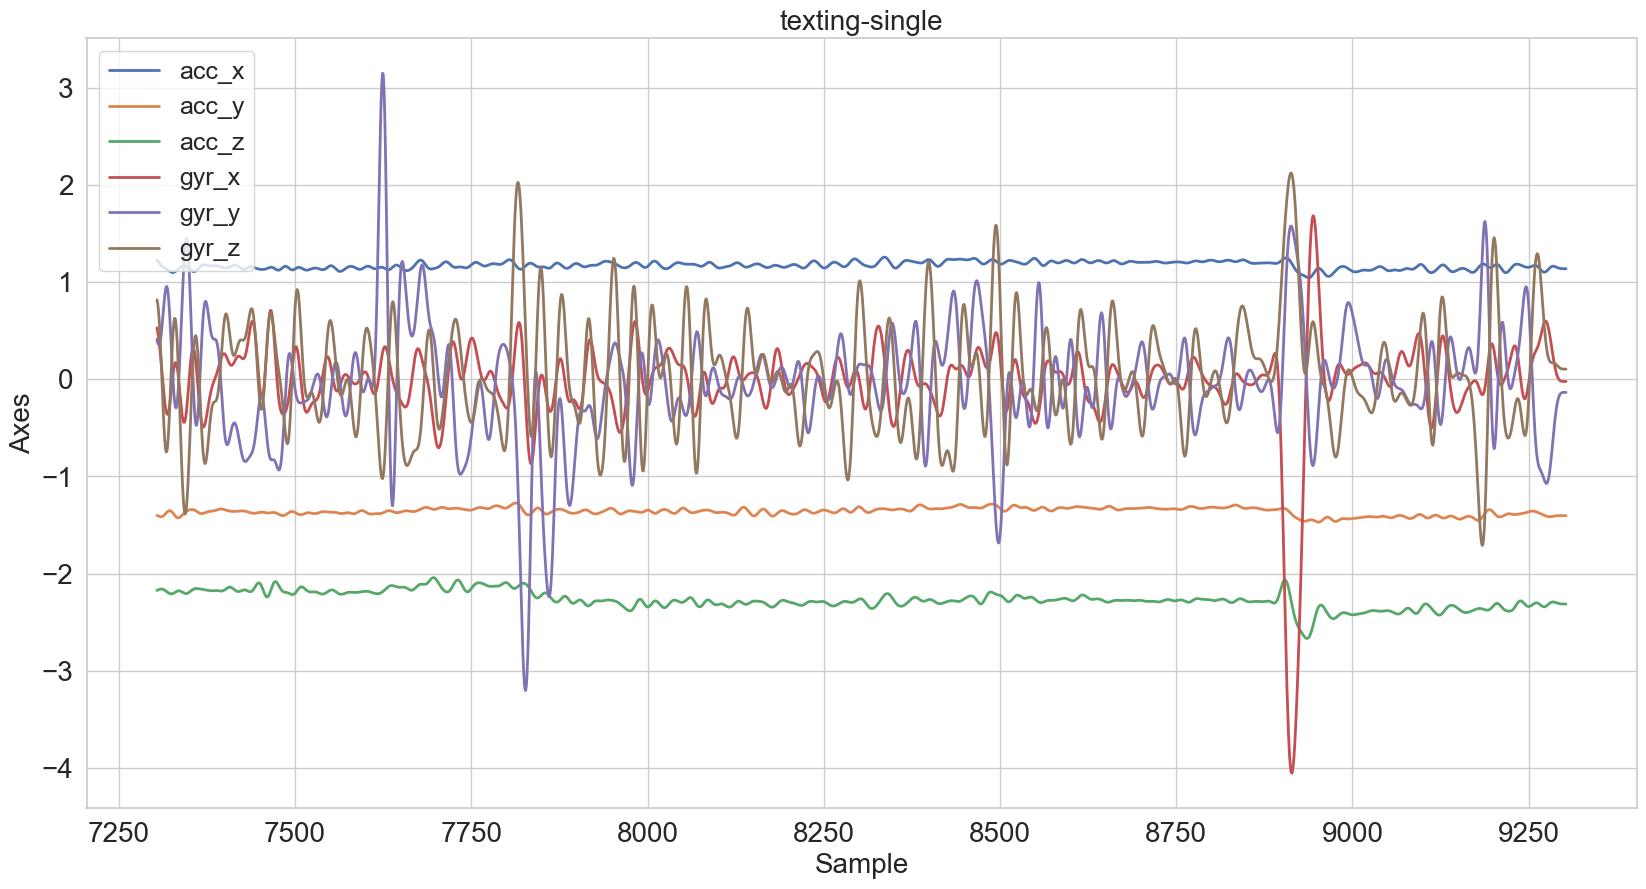

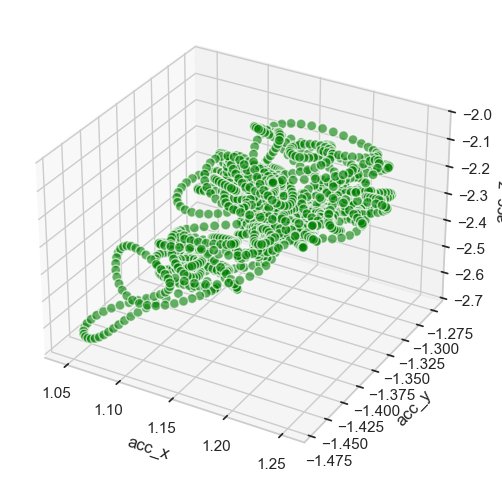

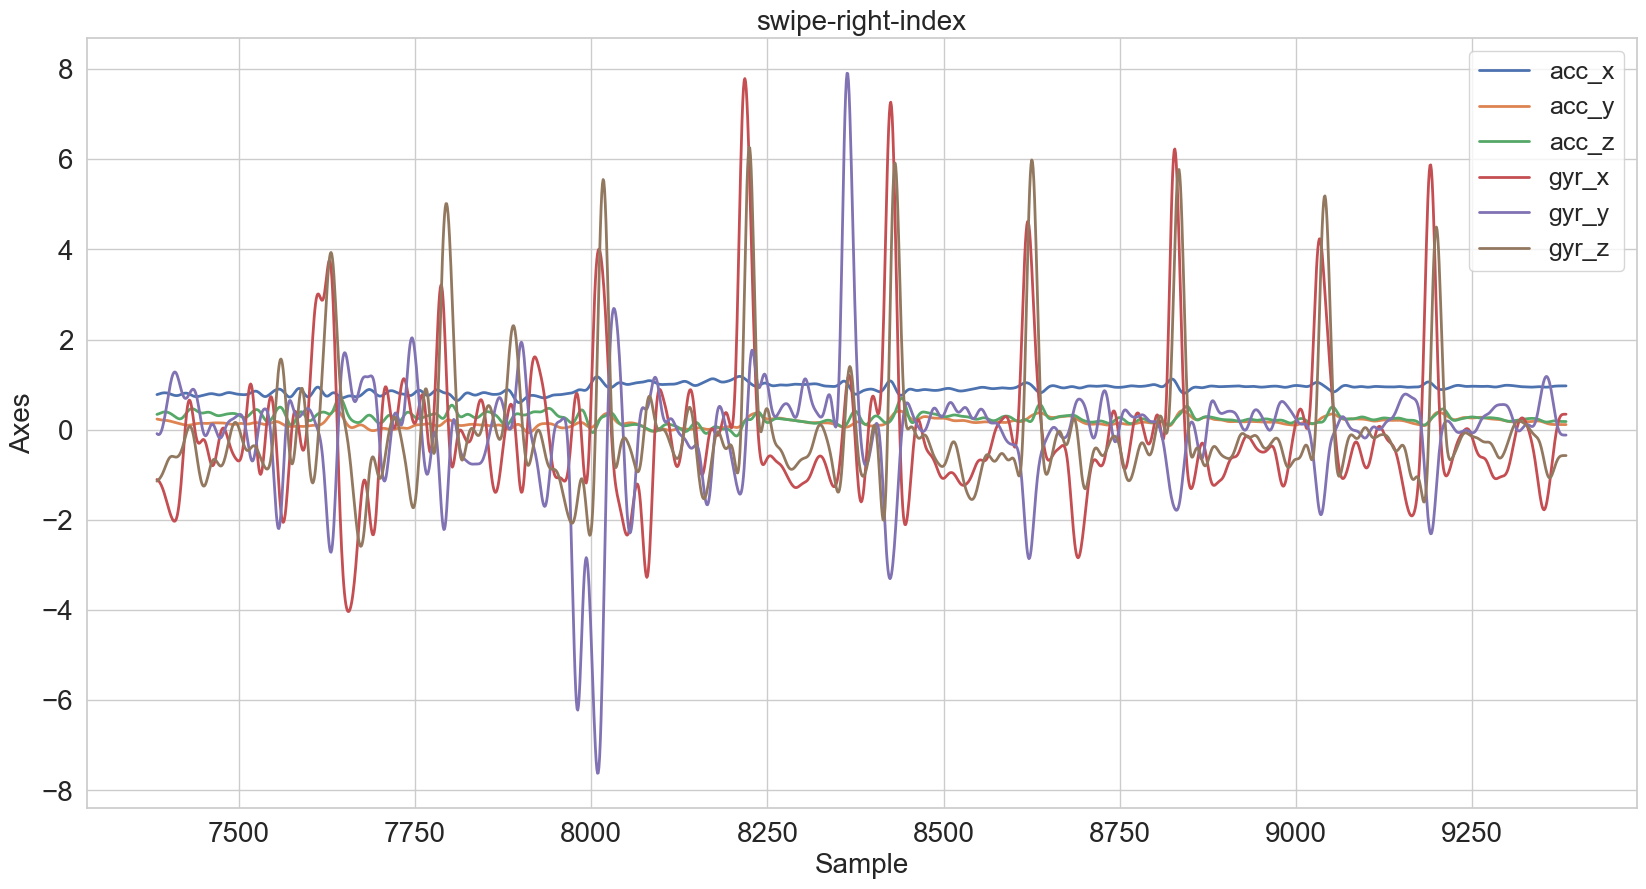

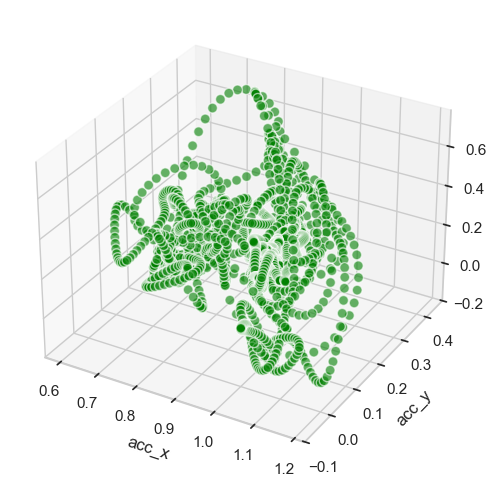

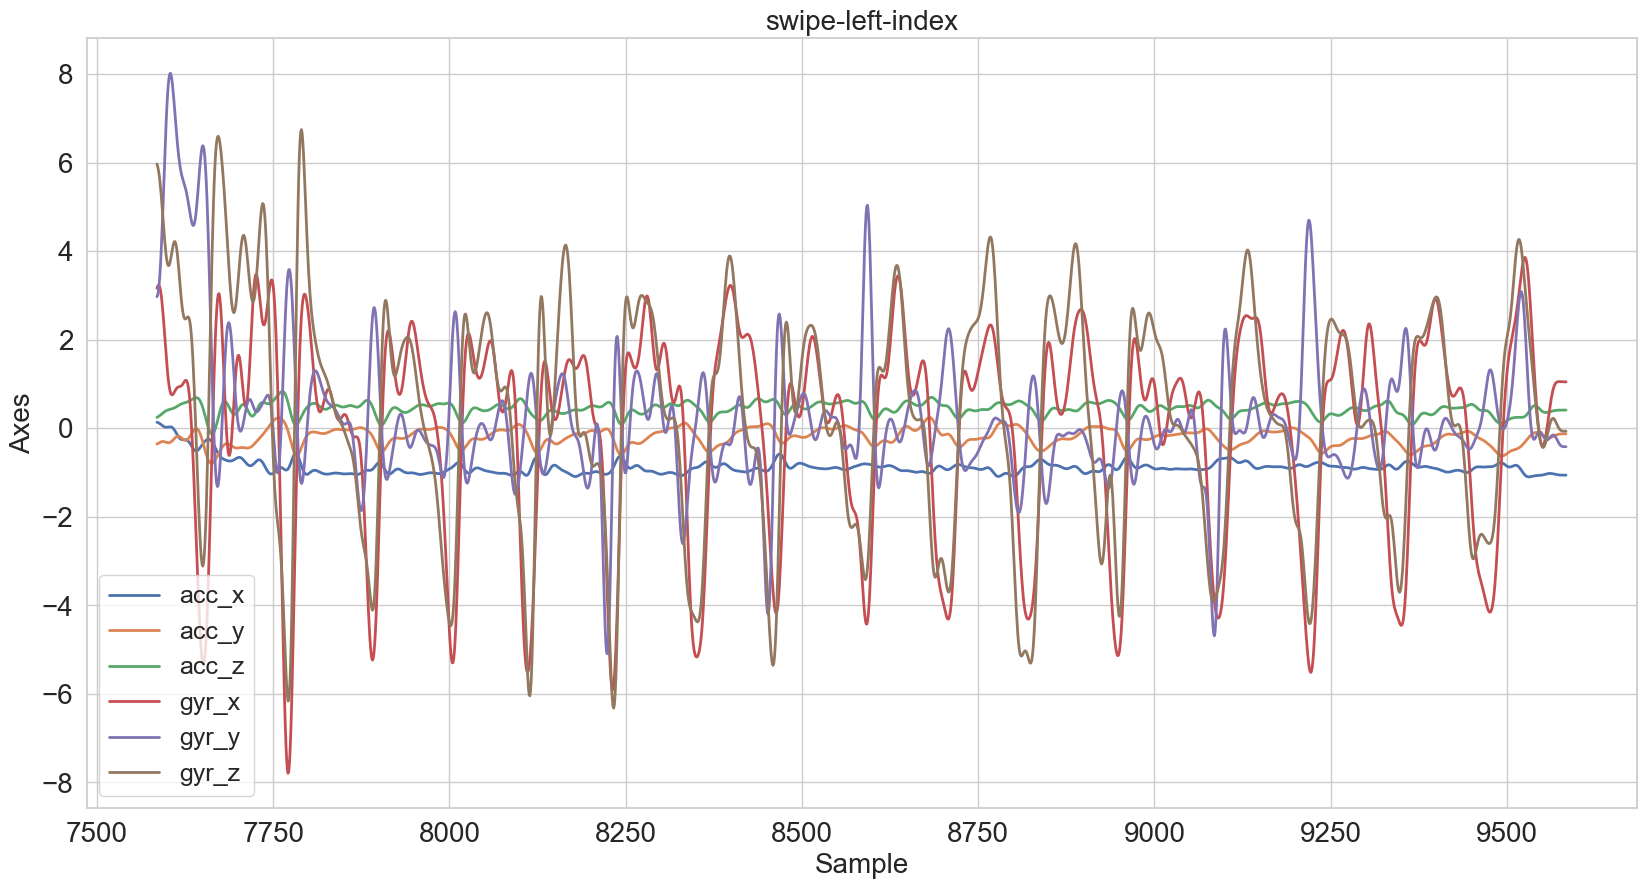

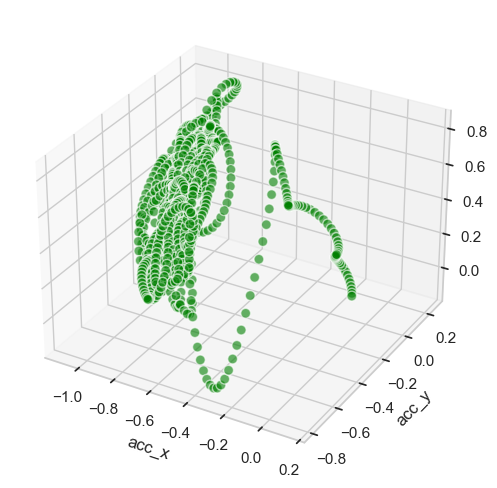

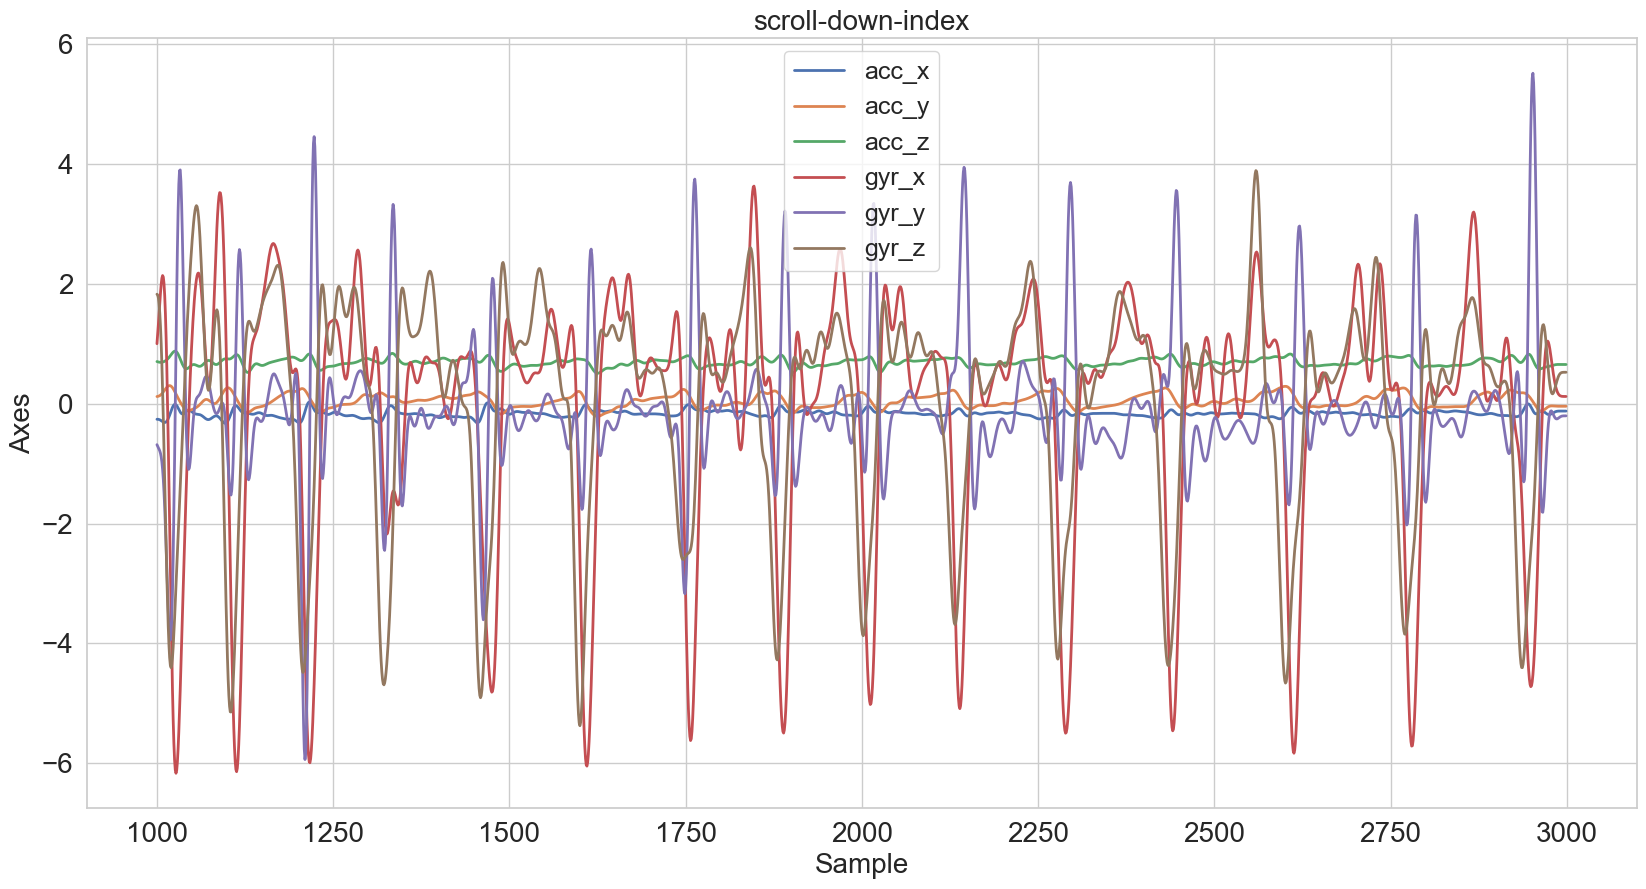

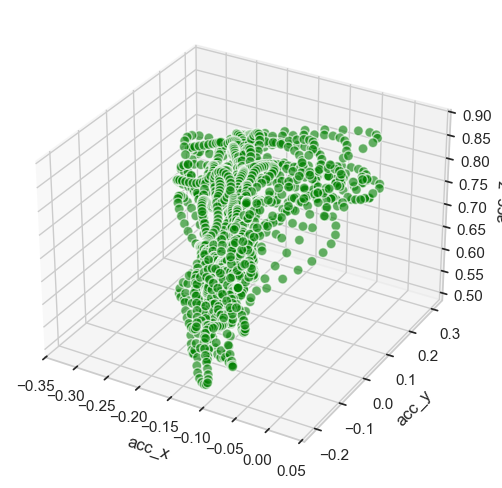

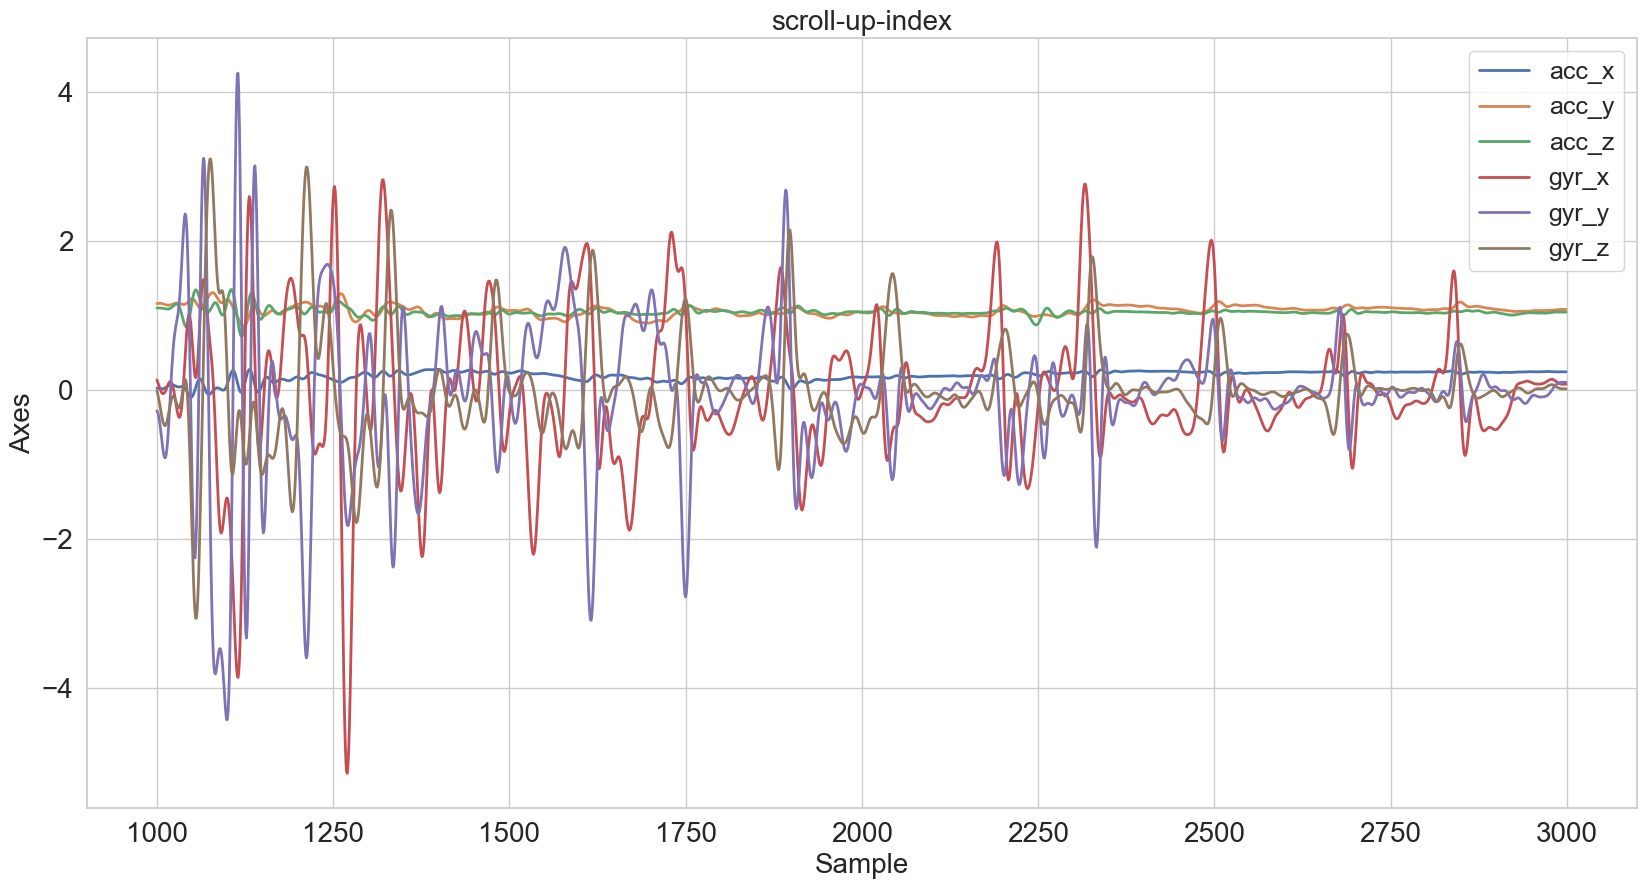

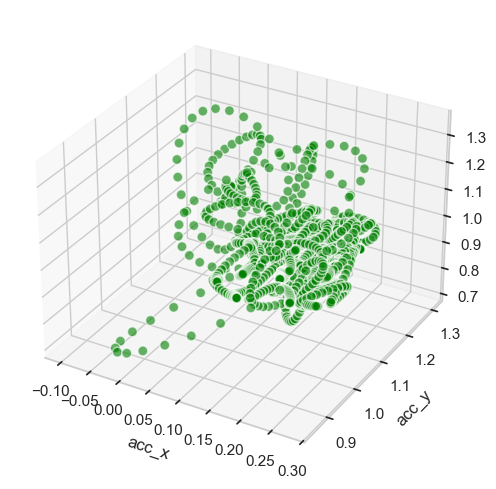

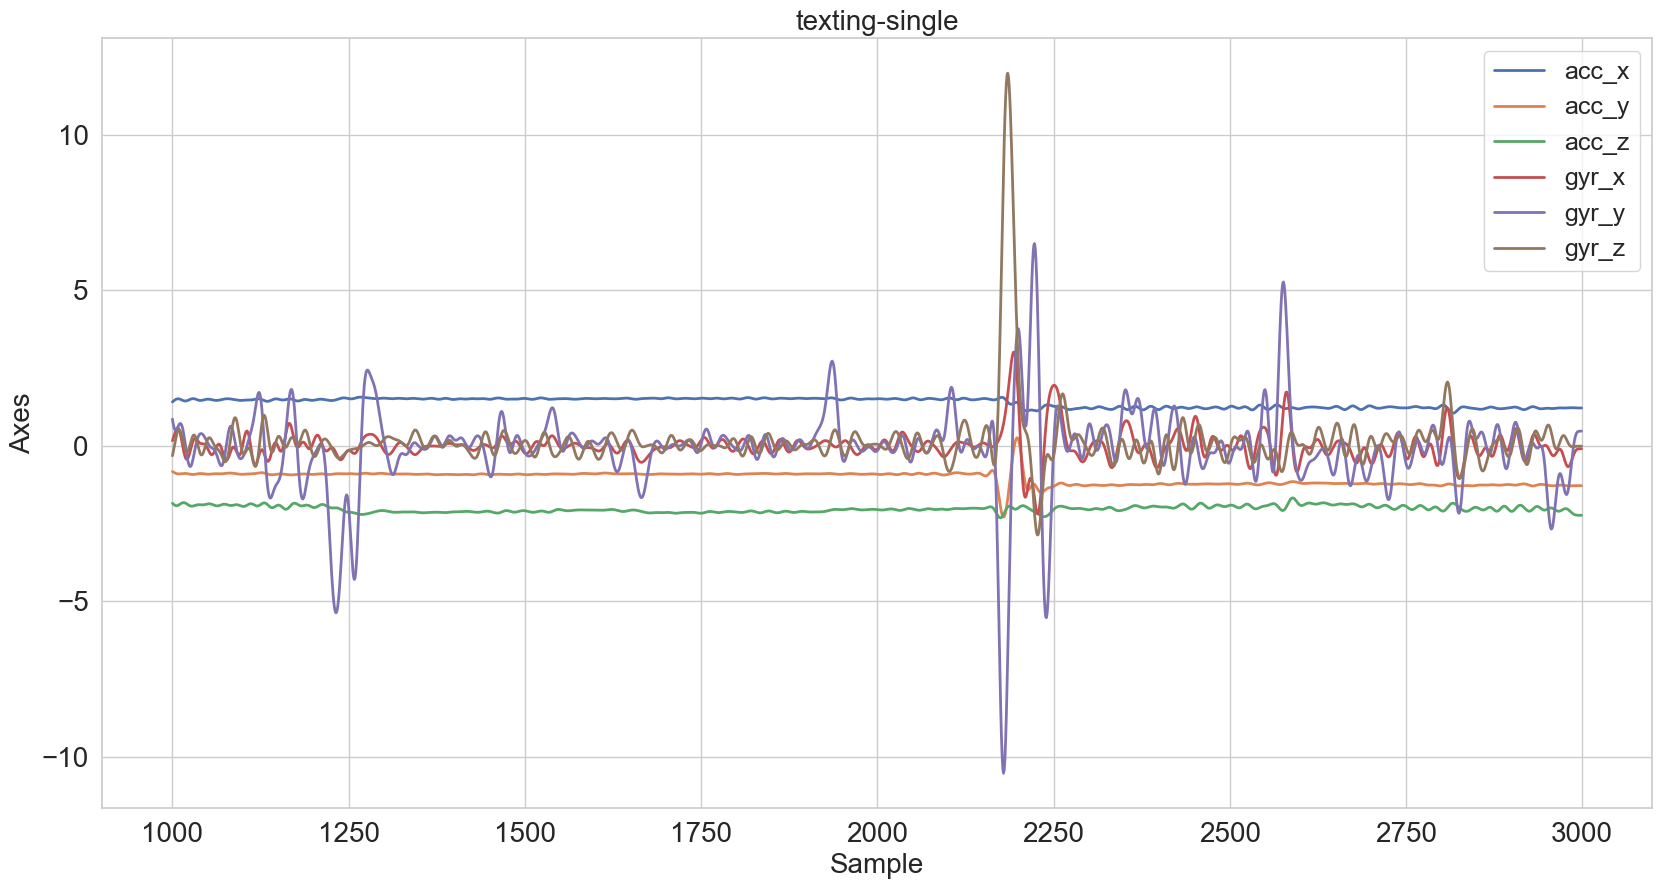

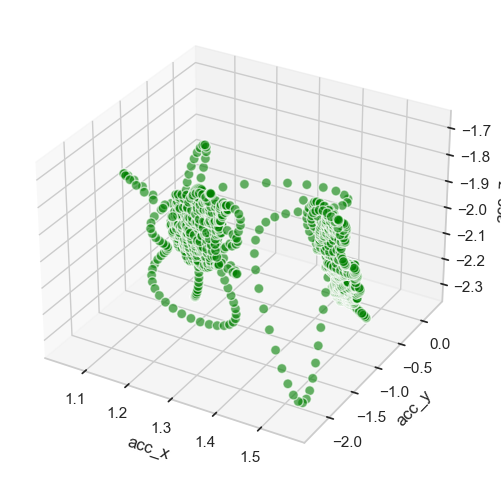

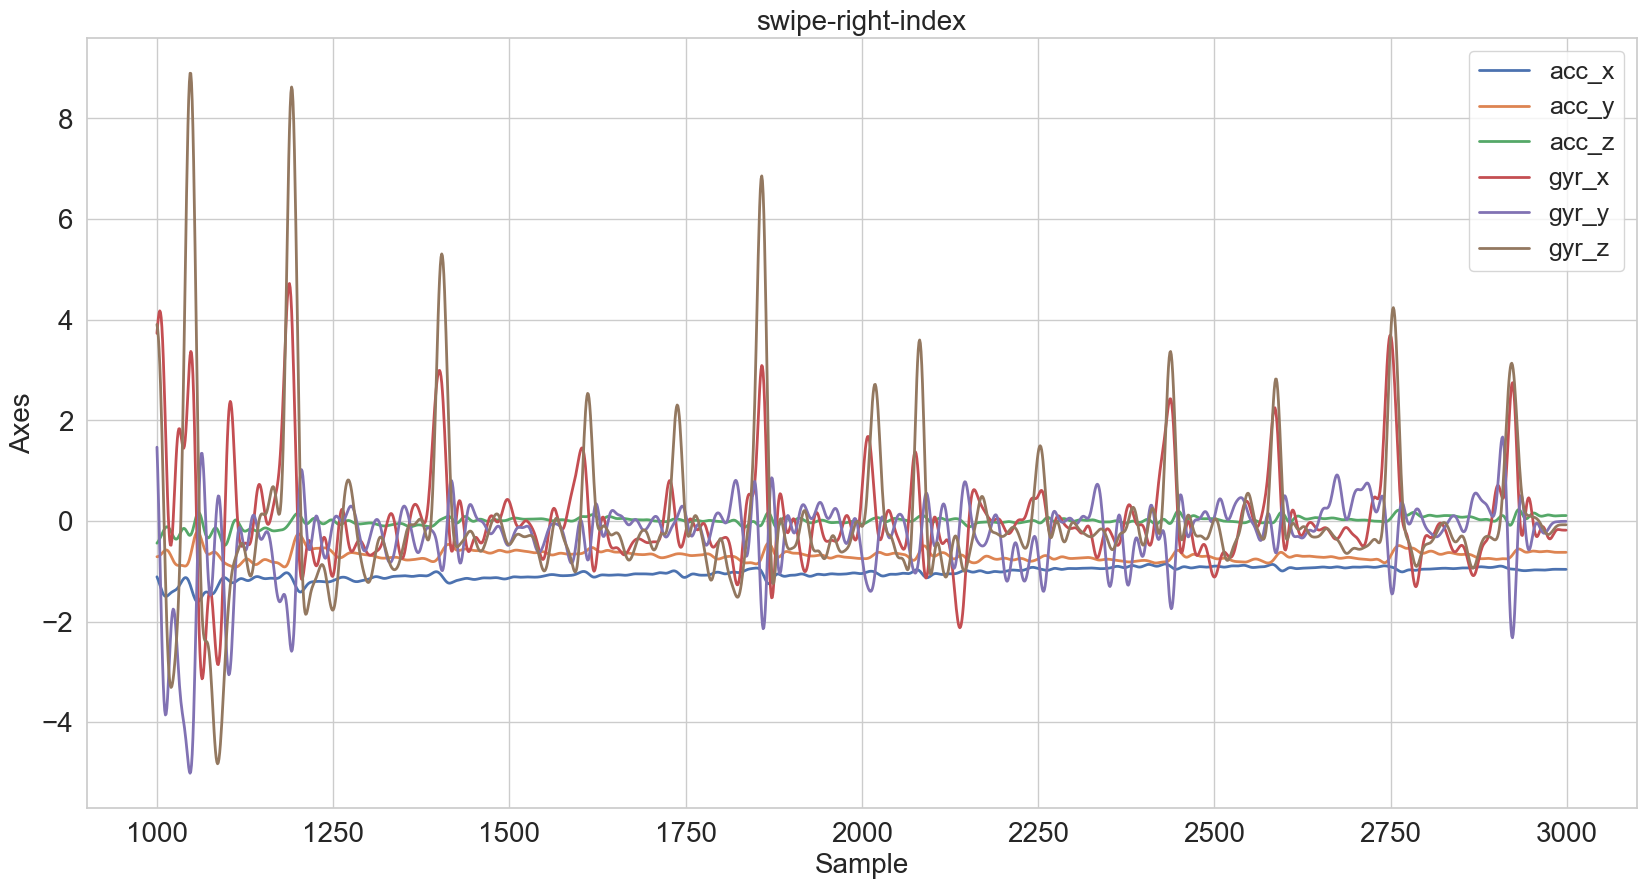

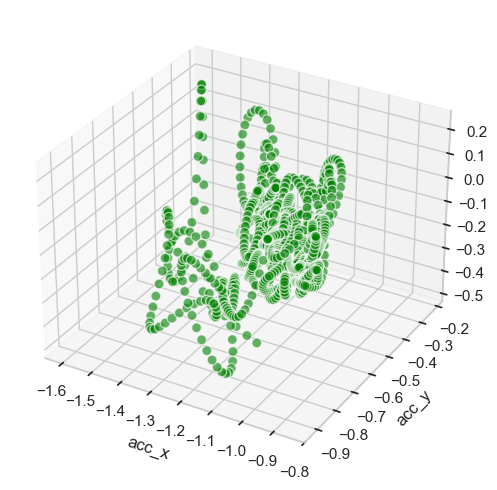

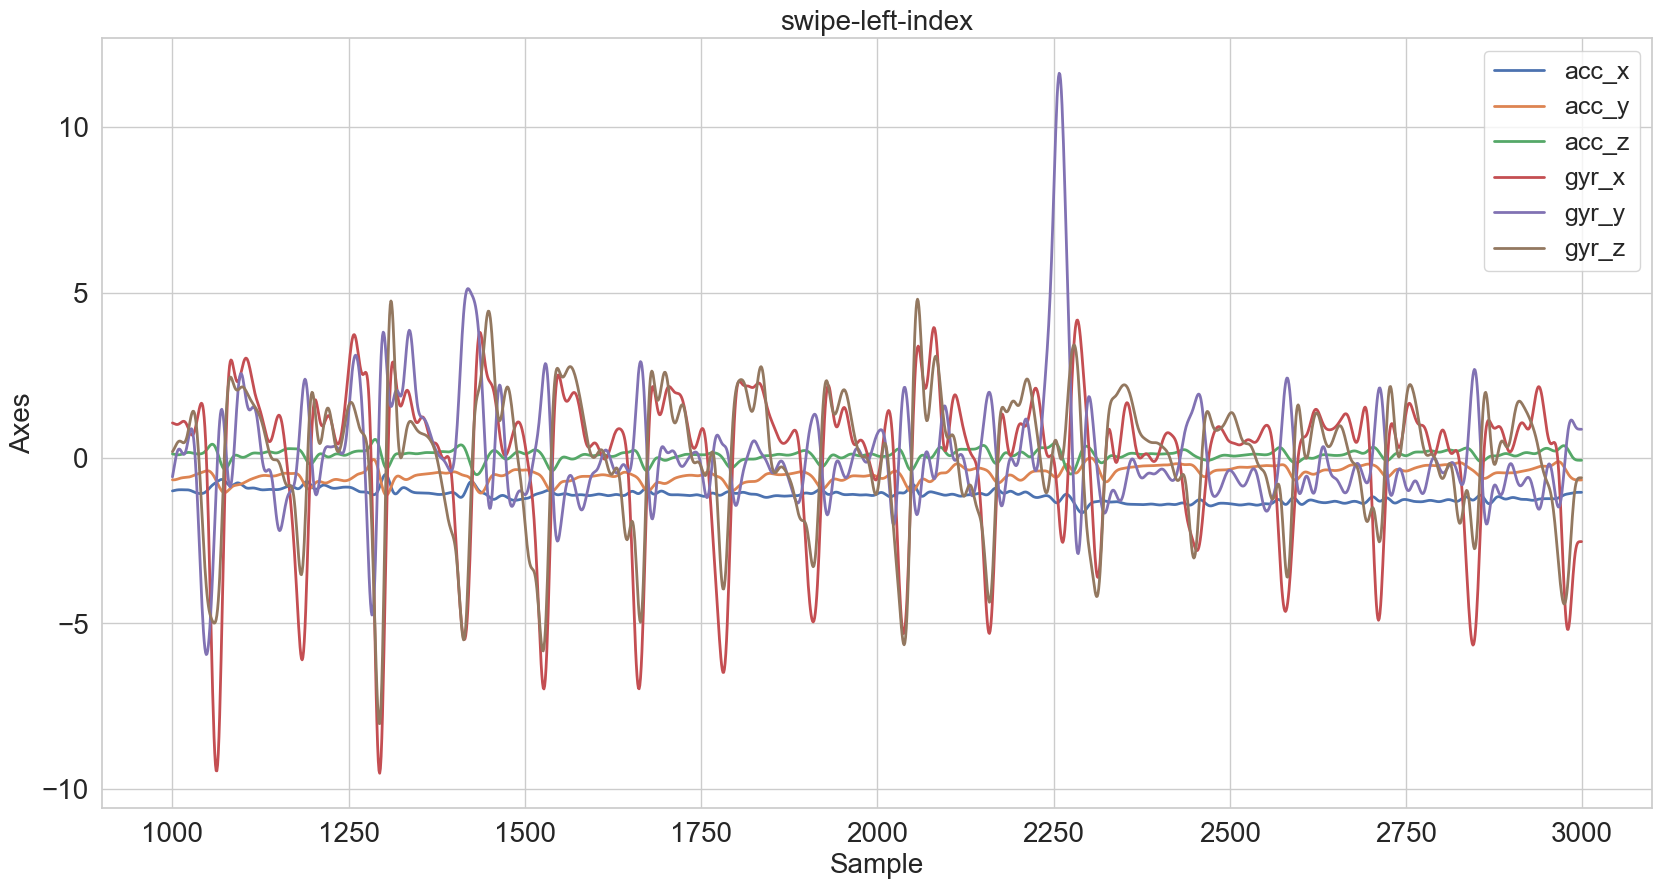

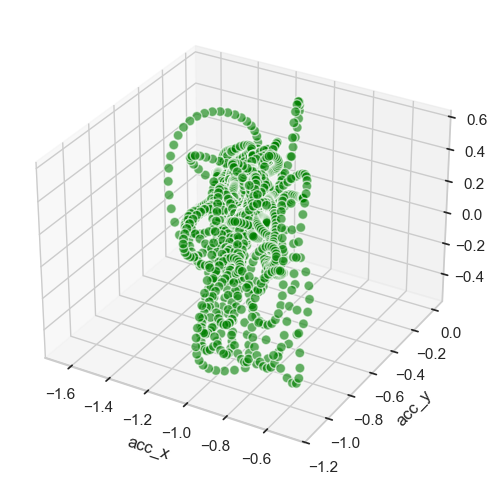

In [ ]:
def window_and_filter_gestures(cleaned_gestures):
    clips_arr = []
    clipped_gestures = {}
    for id, data in cleaned_gestures.items():
        # slice data into windows
        clips = sliding_window_pd(data, ws=2000, overlap=1000, print_stats=False)
        total_clips = len(clips)
        # print(f'Total clips: {total_clips}')
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
        clipped_gestures[id] = fclips
        print(f'GESTURE_ID: {id}')
        plot_instance_time_domain(fclips[1], id)
        # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
        plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])
    return (clipped_gestures, clips_arr)

clipped_train, train_distr = window_and_filter_gestures(gestures_train)
clipped_val, val_distr = window_and_filter_gestures(gestures_val)
print("clipped_train keys: ", clipped_train.keys(), "\nlength: ", len(clipped_train))
print("clipped_val keys: ", clipped_val.keys(), "\nlength: ", len(clipped_val))
print(len(clipped_train['scroll-up-index']), "clips in clipped_train for scroll-up-index")


             Gesture  Total Clips
0  scroll-down-index           24
1    scroll-up-index           25
2     texting-single           24
3  swipe-right-index           24
4   swipe-left-index           25


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/utils_visual.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


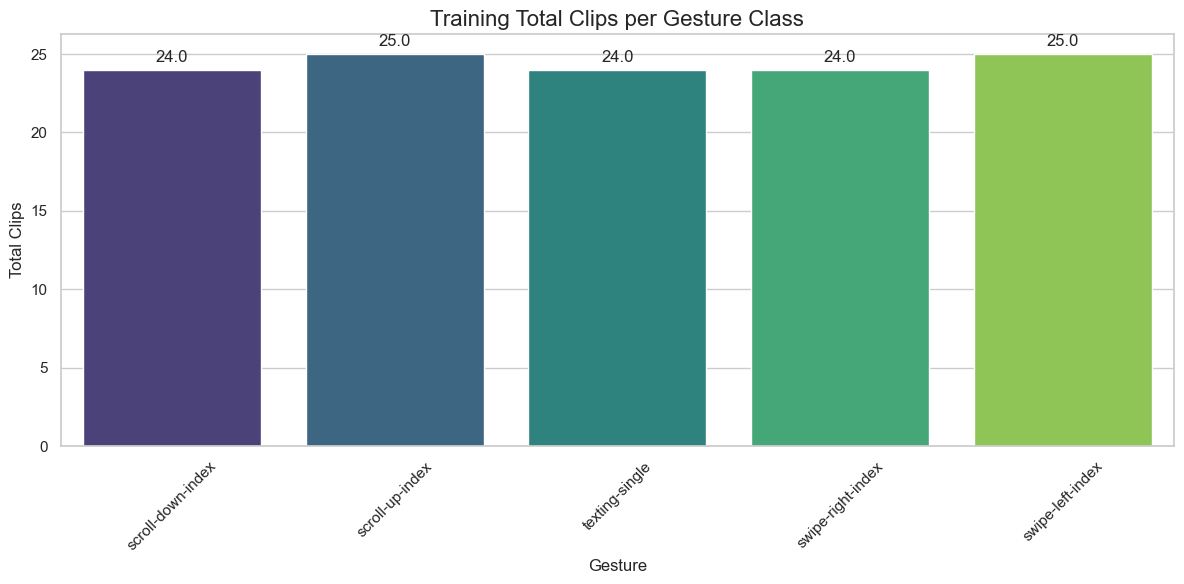

             Gesture  Total Clips
0  scroll-down-index            5
1    scroll-up-index            5
2     texting-single            5
3  swipe-right-index            5
4   swipe-left-index            5


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/utils_visual.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


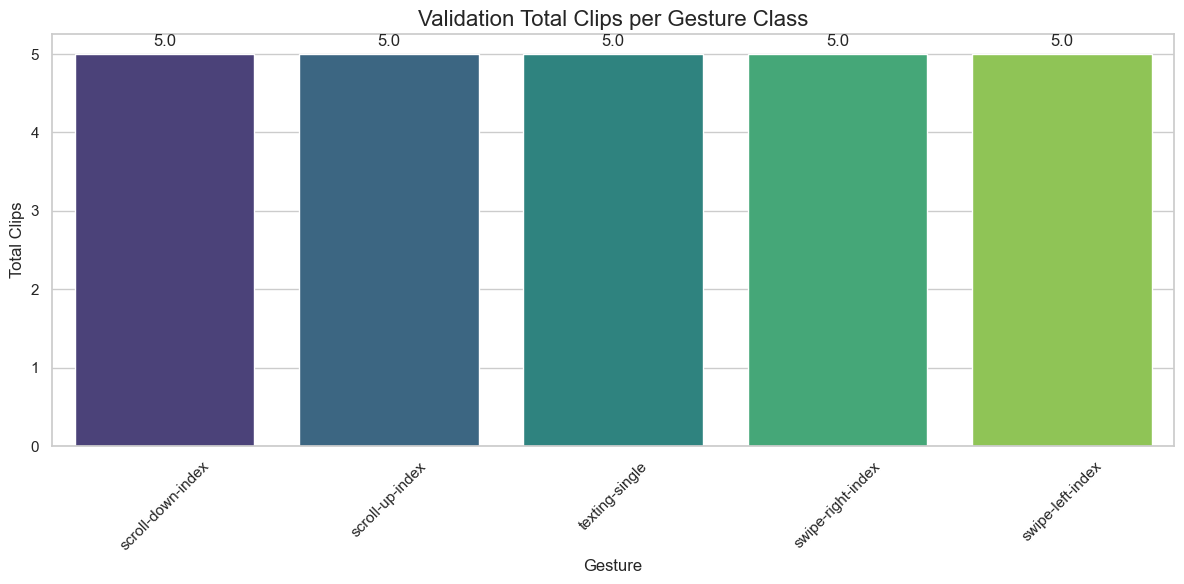

In [43]:
# 2. Convert to a DataFrame for easier plotting
train_distr_df = pd.DataFrame(train_distr)
val_distr_df = pd.DataFrame(val_distr)

print(train_distr_df)
plot_bar(train_distr_df, title='Training Total Clips per Gesture Class')

print(val_distr_df)
plot_bar(val_distr_df, title='Validation Total Clips per Gesture Class')

## We flatten each sample 

In [44]:
# print(clipped_gestures.keys())
print(clipped_train['scroll-down-index'][0])

def flatten_gestures(clips):
    flattened_clips = {}
    for id, clips in clipped_train.items():
        flattened_clips[id] = flatten_instances_df(clips)
    return flattened_clips

train_clips_flattened = flatten_gestures(clipped_train)
val_clips_flattened = flatten_gestures(clipped_val)

print(len(train_clips_flattened['scroll-up-index']), "flattened clips in train_clips_flattened for scroll-up-index")    
print(len(val_clips_flattened['scroll-up-index']), "flattened clips in val_clips_flattened for scroll-up-index")    
print(train_clips_flattened['scroll-up-index'])

         acc_x     acc_y     acc_z     gyr_x     gyr_y     gyr_z
6337 -0.281984 -0.057798  0.665780 -1.743181  1.136015 -0.373138
6338 -0.282272 -0.064933  0.656761 -1.491524  1.108129 -0.139074
6339 -0.282830 -0.072567  0.647319 -1.176993  1.071806  0.138453
6340 -0.283791 -0.080215  0.637924 -0.800799  1.031034  0.452745
6341 -0.285307 -0.087299  0.629090 -0.367308  0.991276  0.794325
...        ...       ...       ...       ...       ...       ...
8332 -0.636259  0.044653  0.652946  2.763408 -1.219564  1.926374
8333 -0.636321  0.044790  0.653007  2.763597 -1.219123  1.926059
8334 -0.636340  0.044831  0.653027  2.763638 -1.218994  1.925959
8335 -0.636344  0.044839  0.653031  2.763644 -1.218968  1.925939
8336 -0.636345  0.044840  0.653031  2.763645 -1.218966  1.925937

[2000 rows x 6 columns]
25 flattened clips in train_clips_flattened for scroll-up-index
25 flattened clips in val_clips_flattened for scroll-up-index
       0         1         2         3          4         5         6

## Classifier - Statistical Learning

### Apply simple classifier

In [45]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [46]:
def prepare_xy(flattened_dict):
    X = pd.concat(flattened_dict.values(), ignore_index=True).to_numpy()
    
    y = []
    for gesture_name, df in flattened_dict.items():
        y.extend([gesture_name] * len(df))
        
    return X, np.array(y)

X_train, y_train = prepare_xy(train_clips_flattened)
X_val, y_val = prepare_xy(val_clips_flattened)

print("X_train shape: ", X_train.shape)
print("Y_train shape: ", y_train.shape)

X_train shape:  (122, 12000)
Y_train shape:  (122,)


### Evaluate classifiers

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SVM Classification Report:
                    precision    recall  f1-score   support

scroll-down-index       1.00      1.00      1.00        24
  scroll-up-index       1.00      1.00      1.00        25
 swipe-left-index       1.00      1.00      1.00        25
swipe-right-index       1.00      1.00      1.00        24
   texting-single       1.00      1.00      1.00        24

         accuracy                           1.00       122
        macro avg       1.00      1.00      1.00       122
     weighted avg       1.00      1.00      1.00       122



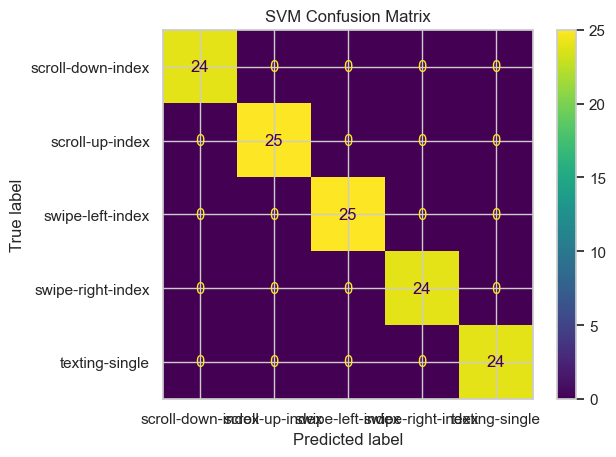

In [ ]:
svm_model = SVC(kernel='rbf', gamma='auto')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)

print("SVM Classification Report:\n", classification_report(y_val, y_pred_svm))
confusion_matrix_svm = confusion_matrix(y_val, y_pred_svm, labels=svm_model.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_svm, display_labels=svm_model.classes_)
disp_svm.plot()
plt.title("SVM Confusion Matrix")
plt.show()

Random Forest Classification Report:
                    precision    recall  f1-score   support

scroll-down-index       1.00      1.00      1.00        24
  scroll-up-index       1.00      1.00      1.00        25
 swipe-left-index       1.00      1.00      1.00        25
swipe-right-index       1.00      1.00      1.00        24
   texting-single       1.00      1.00      1.00        24

         accuracy                           1.00       122
        macro avg       1.00      1.00      1.00       122
     weighted avg       1.00      1.00      1.00       122



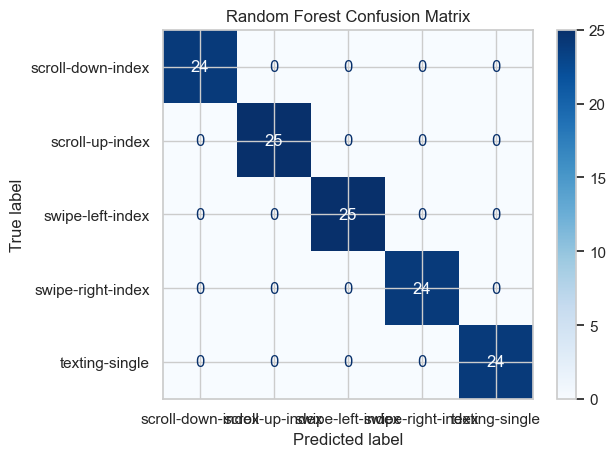

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

print("Random Forest Classification Report:\n", classification_report(y_val, rf_pred))
confusion_matrix_rf = confusion_matrix(y_val, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

Logistic Regression Classification Report:
                    precision    recall  f1-score   support

scroll-down-index       1.00      1.00      1.00        24
  scroll-up-index       1.00      1.00      1.00        25
 swipe-left-index       1.00      1.00      1.00        25
swipe-right-index       1.00      1.00      1.00        24
   texting-single       1.00      1.00      1.00        24

         accuracy                           1.00       122
        macro avg       1.00      1.00      1.00       122
     weighted avg       1.00      1.00      1.00       122



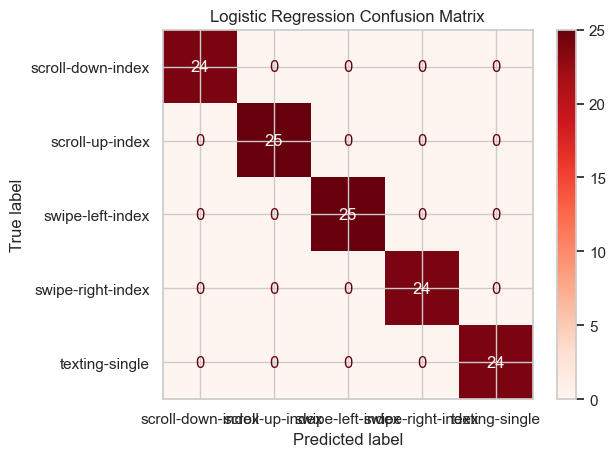

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_val)

print("Logistic Regression Classification Report:\n", classification_report(y_val, log_pred))
confusion_matrix_log = confusion_matrix(y_val, log_pred)
disp_log = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_log, display_labels=log_model.classes_)
disp_log.plot(cmap=plt.cm.Reds)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
from torch import nn

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_val)

print("Logistic Regression Classification Report:\n", classification_report(y_val, log_pred))
confusion_matrix_log = confusion_matrix(y_val, log_pred)
disp_log = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_log, display_labels=log_model.classes_)
disp_log.plot(cmap=plt.cm.Reds)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier